# Introduction

This project focuses on Exploratory Data Analysis (EDA) of a Superstore Sales dataset using Python. The objective was to analyze sales performance, customer behavior, product trends, and business growth patterns through data visualization and statistical insights.

Using Pandas, NumPy, Matplotlib, and Seaborn, I cleaned the dataset, handled missing values, performed data transformation, and created visualizations to uncover meaningful business insights. The analysis helps identify top-performing products, valuable customer segments, preferred shipping methods, regional sales performance, and overall sales trends.


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df=pd.read_csv(r"train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Cleaning data


In [58]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)
df['Order Date'].head()

,Order Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11


In [61]:
df['Postal Code']=df['Postal Code'].fillna(0)

In [62]:
df['Postal Code'].isnull().sum()

np.int64(0)

## Which Product was sell most

In [63]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [64]:
df["Product Name"].head()

,Product Name
0,Bush Somerset Collection Bookcase
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,Self-Adhesive Address Labels for Typewriters b...
3,Bretford CR4500 Series Slim Rectangular Table
4,Eldon Fold 'N Roll Cart System


In [65]:
top=df["Product Name"].value_counts().reset_index().head()
top=top.rename(columns={"count":"Total sales"})
print(top)

              Product Name  Total sales
0          Staple envelope           47
1                  Staples           46
2        Easy-staple paper           44
3  Avery Non-Stick Binders           20
4  Staples in misc. colors           18


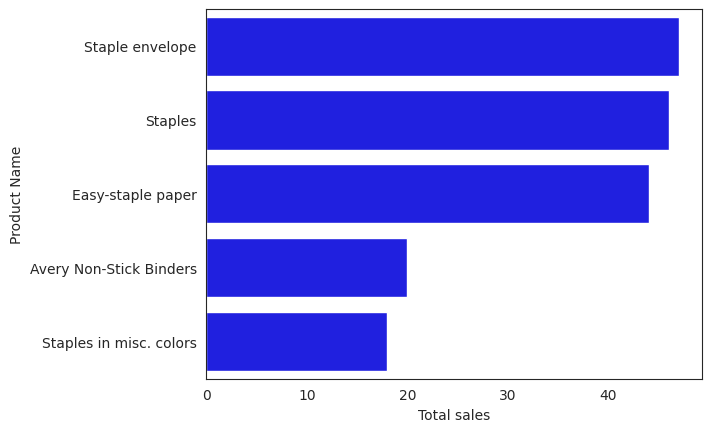

In [66]:
sns.barplot(y=top["Product Name"],x=top["Total sales"],color="blue")
sns.set_style("darkgrid")
sns.set_palette("Set1")

Top selling Product is  Staple envelope


In [67]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [68]:
state=df.groupby("State")["Sales"].sum().sort_values(ascending=False).reset_index().head()
state=state.rename(columns={'Sales':'total Sales'}).head()
print(state)

          State  total Sales
0    California  446306.4635
1      New York  306361.1470
2         Texas  168572.5322
3    Washington  135206.8500
4  Pennsylvania  116276.6500


<Axes: xlabel='State', ylabel='total Sales'>

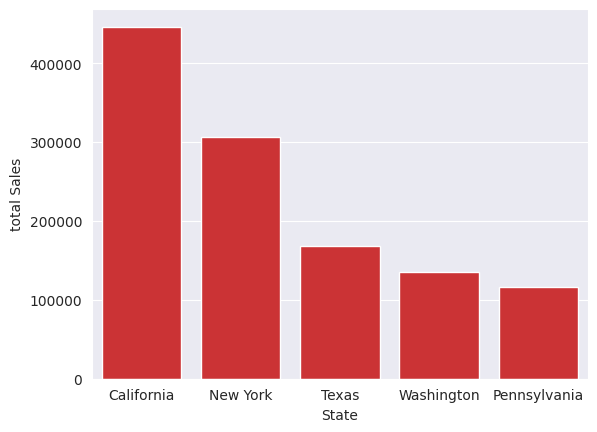

In [69]:
sns.barplot(x=state["State"],y=state["total Sales"])

California has the higest sales


In [70]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [71]:
cus_count=df["Segment"].value_counts().reset_index()
print(cus_count)

       Segment  count
0     Consumer   5101
1    Corporate   2953
2  Home Office   1746


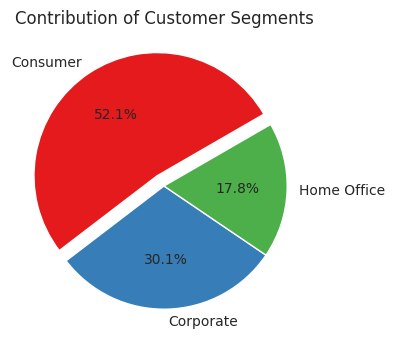

In [72]:
plt.figure(figsize=(10,4))
plt.pie(cus_count["count"],labels=cus_count["Segment"],autopct="%1.1f%%",startangle=30,explode=[0.1,0,0])
plt.title("Contribution of Customer Segments")
plt.show()

Consumer segment has the higest contribution


## Customer loyalty

In [73]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [74]:
group=df.groupby(['Customer ID','Customer Name','Segment'])['Customer ID'].value_counts().sort_values(ascending=False).reset_index()
print(group)

    Customer ID      Customer Name      Segment  count
0      WB-21850      William Brown     Consumer     35
1      PP-18955         Paul Prost  Home Office     34
2      MA-17560       Matt Abelman  Home Office     34
3      JL-15835           John Lee     Consumer     33
4      SV-20365        Seth Vernon     Consumer     32
..          ...                ...          ...    ...
788    CJ-11875       Carl Jackson    Corporate      1
789    AO-10810  Anthony O'Donnell    Corporate      1
790    LD-16855       Lela Donovan    Corporate      1
791    RE-19405    Ricardo Emerson     Consumer      1
792    JR-15700     Jocasta Rupert     Consumer      1

[793 rows x 4 columns]


Most repeated cutomer belong to Consumer and Home Office segment hence they are more loyal.
William Brown is most loyal customer

## Most preffered shipment

In [75]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [76]:
shipment=df['Ship Mode'].value_counts().reset_index()
print(shipment)

        Ship Mode  count
0  Standard Class   5859
1    Second Class   1902
2     First Class   1501
3        Same Day    538


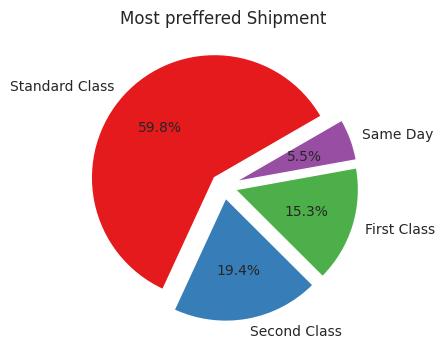

In [77]:
plt.figure(figsize=(10,4))
plt.pie(shipment['count'],labels=shipment['Ship Mode'],autopct="%1.1f%%",startangle=30,explode=[0.1,0.1,0.1,0.1])
plt.title("Most preffered Shipment")
plt.show()

Most preffered shipment is Standard class

Which state has most customer

In [78]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96


In [79]:
stcus=df["State"].value_counts(ascending=False).reset_index().head()
print(stcus)

          State  count
0    California   1946
1      New York   1097
2         Texas    973
3  Pennsylvania    582
4    Washington    504


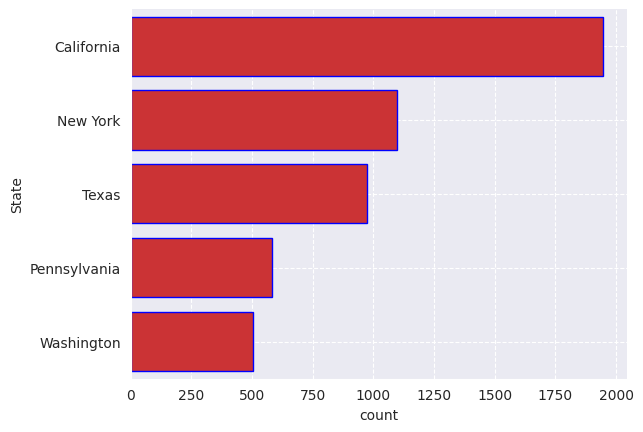

In [80]:
sns.barplot(y=stcus['State'],x=stcus['count'],edgecolor='blue')
sns.set_style('dark')
sns.despine()
plt.grid(linestyle='--')

California has the most Customer


## Which is the most selling category ?

In [81]:
sale=df["Category"].value_counts(ascending=False).reset_index()
print(sale)

          Category  count
0  Office Supplies   5909
1        Furniture   2078
2       Technology   1813


Office Supplies is the most selling category

## Which year has the most sale ?

In [82]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96


In [83]:
date=df["Order Date"].dt.year

In [84]:
group_sale=df.groupby(date)["Sales"].sum().sort_values(ascending=False).reset_index()

In [85]:
print(group_sale)

   Order Date        Sales
0        2018  722052.0192
1        2017  600192.5500
2        2015  479856.2081
3        2016  459436.0054


Text(0.5, 1.0, 'Sales distribution by year')

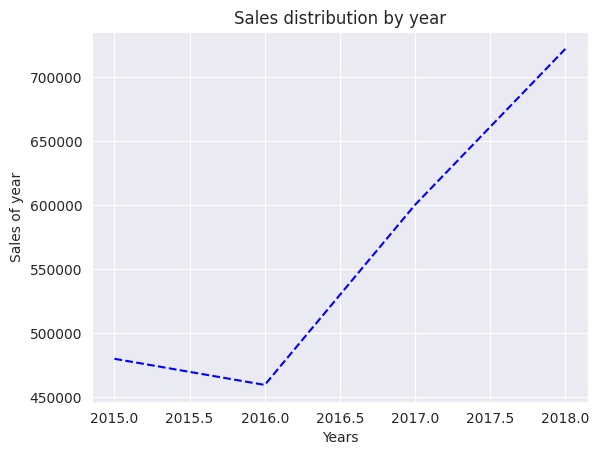

In [86]:
sns.lineplot(x=group_sale['Order Date'],y=group_sale['Sales'],linestyle='--',color='blue')
sns.set_style("white")
sns.set_palette("Set1")
plt.xlabel("Years")
plt.grid(True)
plt.ylabel("Sales of year")
plt.title("Sales distribution by year")


There was growth in sales from 2016 onwards and 2018 has the higest sales among all year

## Quarterly sales of 2018

> Add blockquote



  Order Date        Sales
0 2018-03-31  122260.8842
1 2018-06-30  127558.6200
2 2018-09-30  193815.8400
3 2018-12-31  278416.6750


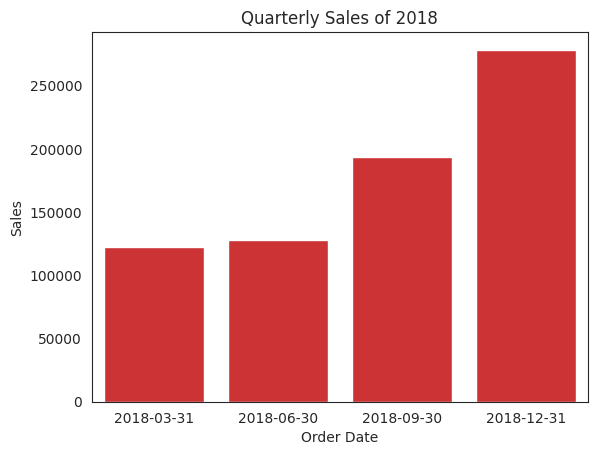

In [100]:
sale2018 = df[df["Order Date"].dt.year == 2018]

group = sale2018.resample('QE', on='Order Date')['Sales'].sum().reset_index()

print(group)

sns.barplot(x='Order Date', y='Sales', data=group)

plt.title("Quarterly Sales of 2018")
plt.show()

Q4 has the done higest sales